## Histogram settings

Edit the values in the **plot settings** cell below:

| Variable | What it controls |
|----------|------------------|
| `HIST_BINS` | **Number of bars** per subplot (e.g. `15`, `30`). Use an integer. |
| `BIN_WIDTH` | **Width of each bar** in mm (e.g. `0.05`). Set to `None` to use `HIST_BINS` instead. |
| `FIG_WIDTH`, `FIG_HEIGHT` | Overall figure size in inches (larger = bigger on screen). |

**Examples**

- Wider, smoother bars: `HIST_BINS = 10` or `BIN_WIDTH = 0.1`
- Finer detail: `HIST_BINS = 40` or `BIN_WIDTH = 0.02`
- Fixed 0.05 mm bins: `BIN_WIDTH = 0.05` and `HIST_BINS = None`

Re-run the plotting cell after changing any value.

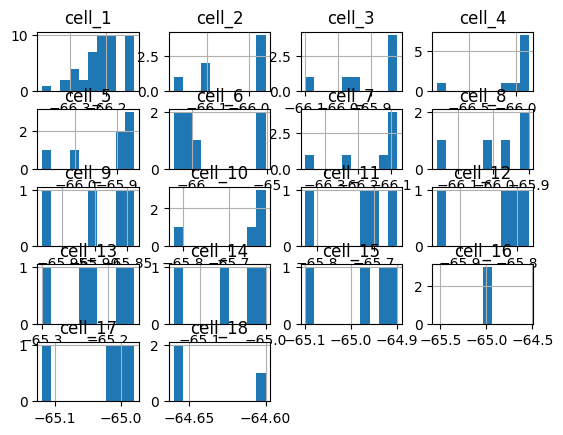

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Plot settings (change these) ---
HIST_BINS = 20          # number of bars per cell; ignored if BIN_WIDTH is set
BIN_WIDTH = None        # bar width in mm, e.g. 0.05; set None to use HIST_BINS
FIG_WIDTH = 20          # figure width (inches)
FIG_HEIGHT = 12         # figure height (inches)
N_COLS = 6              # subplot grid: rows × cols should fit all columns

# Notebook cwd is usually this folder; fall back if run from repo root
csv_path = Path('hitpoints.csv')
if not csv_path.exists():
    csv_path = Path('results/Auto-runs/hitpoints.csv')

df = pd.read_csv(csv_path)
numeric = df.apply(pd.to_numeric, errors='coerce')

if BIN_WIDTH is not None:
    lo, hi = numeric.min().min(), numeric.max().max()
    bins = np.arange(lo - BIN_WIDTH, hi + 2 * BIN_WIDTH, BIN_WIDTH)
else:
    bins = HIST_BINS

n_cells = numeric.shape[1]
n_rows = int(np.ceil(n_cells / N_COLS))

plt.style.use('ggplot')
fig, axes = plt.subplots(
    n_rows, N_COLS,
    figsize=(FIG_WIDTH, FIG_HEIGHT),
    constrained_layout=True,
    squeeze=False,
)

bar_color = '#4C78A8'
edge_color = '#2F4B7C'

for ax, col in zip(axes.flat, numeric.columns):
    series = numeric[col].dropna()
    ax.hist(
        series,
        bins=bins,
        color=bar_color,
        edgecolor=edge_color,
        linewidth=0.6,
        alpha=0.85,
    )
    ax.set_title(col.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.set_xlabel('Z hitpoint (mm)', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.35)

for ax in axes.flat[n_cells:]:
    ax.set_visible(False)

fig.suptitle('Hitpoint distributions by cell', fontsize=16, fontweight='bold', y=1.02)
plt.show()